In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_csv(
    "electricity.csv",
    na_values='?',
    low_memory=False,
    nrows=50000
)

print(df.head())

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [3]:
df = df.dropna()

print(df.isnull().sum())

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [4]:
columns = [
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'Global_active_power'
]

for col in columns:
    df[col] = pd.to_numeric(df[col])

In [5]:
X = df[[
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]]

y = df['Global_active_power']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("MODEL TRAINED SUCCESSFULLY!")

MODEL TRAINED SUCCESSFULLY!


In [8]:
predictions = model.predict(X_test)

In [9]:
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.9978363165755944
Mean Absolute Error: 0.03944706376712065


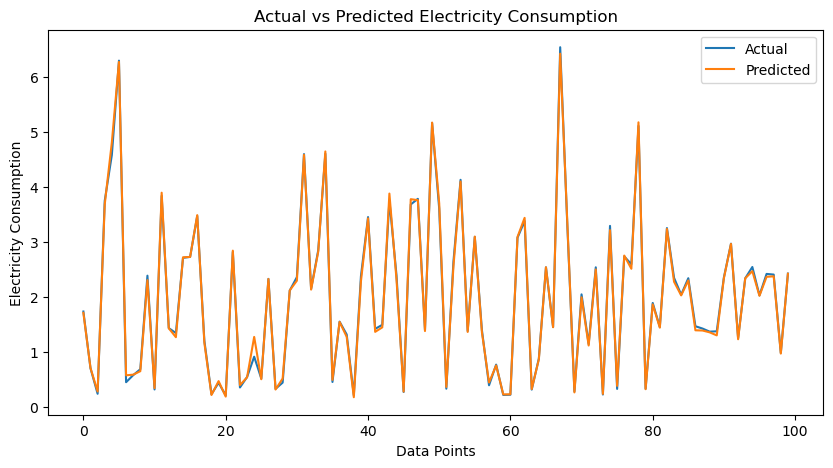

In [10]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.xlabel("Data Points")
plt.ylabel("Electricity Consumption")
plt.title("Actual vs Predicted Electricity Consumption")

plt.legend()

plt.show()

In [11]:
import pickle

with open("electricity_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("MODEL SAVED SUCCESSFULLY!")

MODEL SAVED SUCCESSFULLY!
